GENERATED SYNTHETIC IMAGE


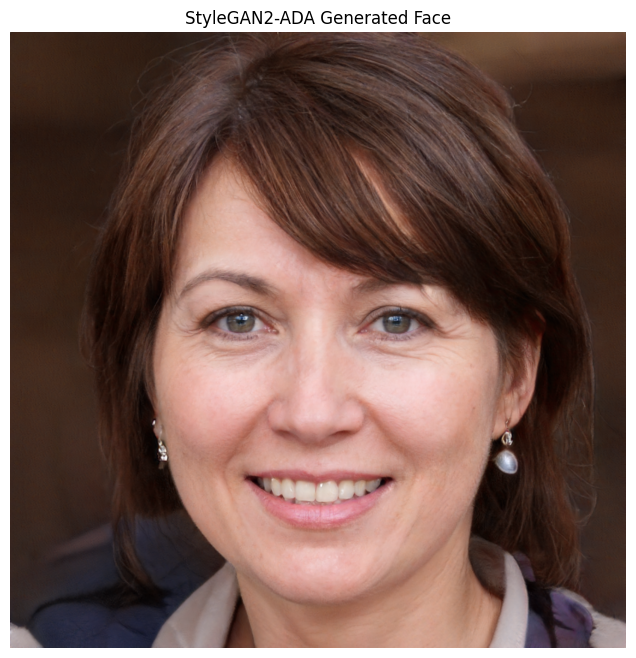

Generated images: 100
Example: /content/generated_images/fake_0000.png

GENERATED IMAGE GRID


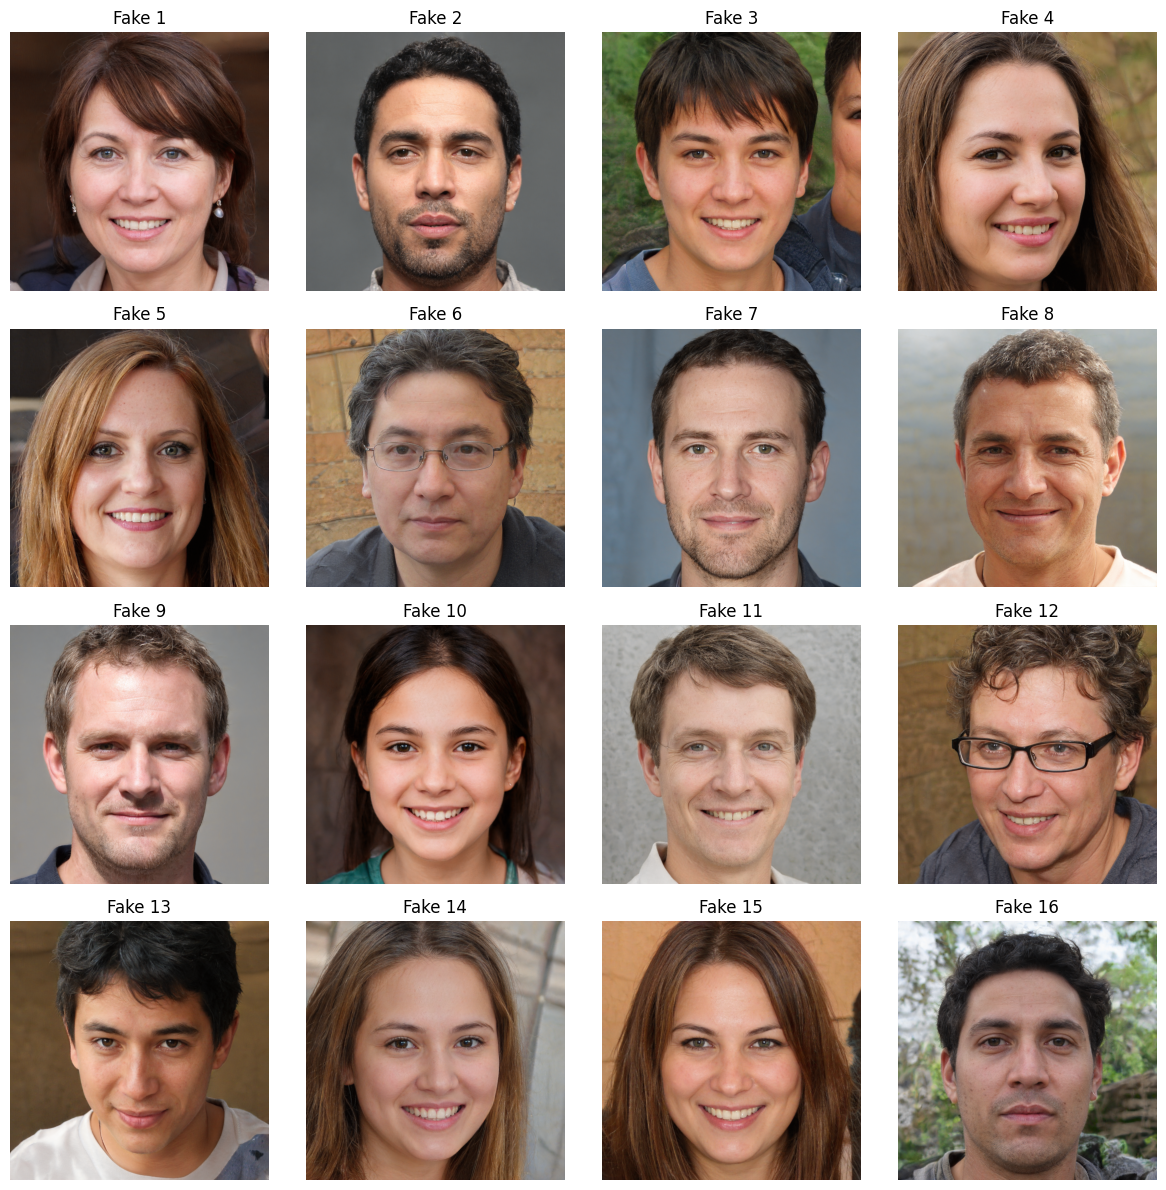


INCEPTION SCORE


/usr/local/lib/python3.13/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Inception Score: 2.01 ± 0.37

FID SCORE
Real images not found.
FID cannot be calculated yet.

FINAL RESULTS
Images generated : 100
Inception Score  : 2.01 ± 0.37


In [3]:
import os
import glob
import torch
import matplotlib.pyplot as plt
from PIL import Image

GENERATED_DIR = "/content/generated_images"
REAL_DIR = "/content/real_images"

# ------------------------------------------------------------
# 1. SHOW GENERATED FAKE IMAGE(S)
# ------------------------------------------------------------

fake_files = sorted(
    glob.glob(f"{GENERATED_DIR}/fake_*.png")
)

print("=" * 60)
print("GENERATED SYNTHETIC IMAGE")
print("=" * 60)

if len(fake_files) == 0:
    print("No generated images found.")
else:

    # Show first generated image
    img = Image.open(fake_files[0])

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("StyleGAN2-ADA Generated Face")
    plt.show()

    print("Generated images:", len(fake_files))
    print("Example:", fake_files[0])

# ------------------------------------------------------------
# 2. SHOW REAL IMAGE FOR COMPARISON
# ------------------------------------------------------------

real_files = sorted(
    glob.glob(f"{REAL_DIR}/real_*.png")
)

if len(real_files) > 0:

    print("\n" + "=" * 60)
    print("REAL IMAGE")
    print("=" * 60)

    img = Image.open(real_files[0])

    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Real CelebA Face")
    plt.show()

# ------------------------------------------------------------
# 3. SHOW FAKE IMAGE GRID
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("GENERATED IMAGE GRID")
print("=" * 60)

NUM_SHOW = min(16, len(fake_files))

fig, axes = plt.subplots(
    4,
    4,
    figsize=(12, 12)
)

for i, ax in enumerate(axes.flat):

    if i < NUM_SHOW:

        img = Image.open(
            fake_files[i]
        )

        ax.imshow(img)
        ax.set_title(
            f"Fake {i + 1}"
        )

    ax.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. CALCULATE INCEPTION SCORE AGAIN
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("INCEPTION SCORE")
print("=" * 60)

# If 'generated' still exists from the previous cell,
# use it directly. Otherwise load the saved images.

if "generated" in globals():

    imgs = generated

else:

    from torchvision import transforms

    transform = transforms.ToTensor()

    loaded = []

    for f in fake_files:

        loaded.append(
            transform(
                Image.open(f).convert("RGB")
            )
        )

    imgs = torch.stack(loaded)

imgs_uint8 = (
    imgs * 255
).clamp(
    0,
    255
).to(
    torch.uint8
)

from torch.utils.data import DataLoader, TensorDataset
from torchmetrics.image.inception import InceptionScore

dataset = TensorDataset(
    imgs_uint8
)

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=False
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

is_metric = InceptionScore(
    normalize=False
).to(device)

with torch.no_grad():

    for batch in loader:

        is_metric.update(
            batch[0].to(device)
        )

mean, std = is_metric.compute()

print(
    f"Inception Score: "
    f"{mean.item():.2f} ± {std.item():.2f}"
)

# ------------------------------------------------------------
# 5. CALCULATE FID
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FID SCORE")
print("=" * 60)

if len(real_files) == 0:

    print(
        "Real images not found."
        "\nFID cannot be calculated yet."
    )

else:

    import subprocess
    import sys

    result = subprocess.run(
        [
            sys.executable,
            "-m",
            "pytorch_fid",
            REAL_DIR,
            GENERATED_DIR
        ],
        capture_output=True,
        text=True
    )

    print(
    )
        result.stdout

# ------------------------------------------------------------
# 6. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(
    f"Images generated : {len(fake_files)}"
)

print(
    f"Inception Score  : "
    f"{mean.item():.2f} ± {std.item():.2f}"
)

if len(real_files) > 0:
    print(
        "FID              : calculated above"
    )

print("=" * 60)